<a href="https://colab.research.google.com/github/mtalhak003/AI-ML-Deep-Learning/blob/main/Transformer_Based_Daily_Gold_Price_Forecasting_Using_Historical_Time_Series_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [11]:
data = yf.download("GC=F", start="2010-01-01", end="2026-01-01", auto_adjust=True)

print(data.head())
print(data.shape)

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2010-01-04  1117.699951  1122.300049  1097.099976  1117.699951    184
2010-01-05  1118.099976  1126.500000  1115.000000  1118.099976     53
2010-01-06  1135.900024  1139.199951  1120.699951  1135.900024    363
2010-01-07  1133.099976  1133.099976  1129.199951  1133.099976     56
2010-01-08  1138.199951  1138.199951  1122.699951  1138.199951     54
(4023, 5)


In [12]:
data = data[["Close"]].dropna()

print(data.head())
print(data.shape)

Price             Close
Ticker             GC=F
Date                   
2010-01-04  1117.699951
2010-01-05  1118.099976
2010-01-06  1135.900024
2010-01-07  1133.099976
2010-01-08  1138.199951
(4023, 1)


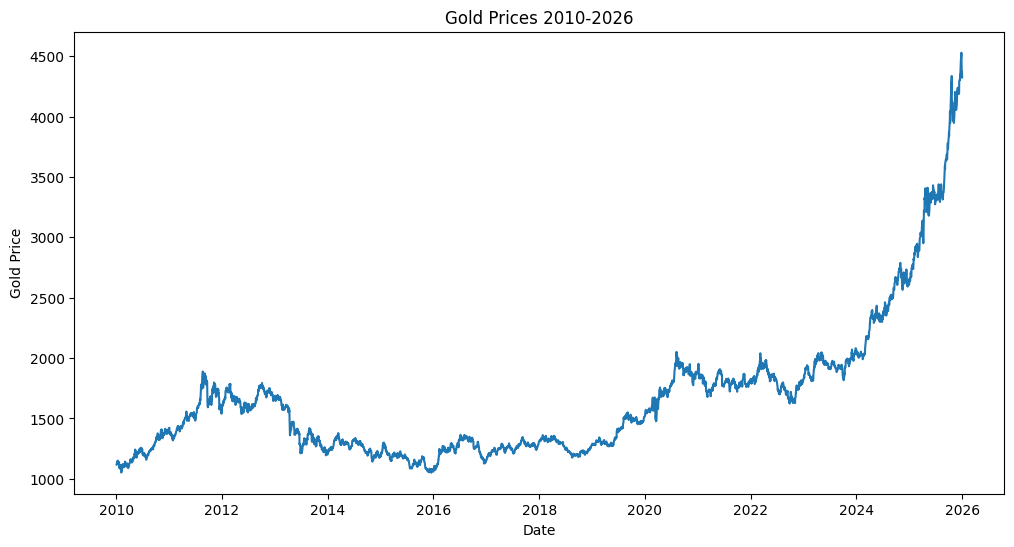

In [13]:

plt.figure(figsize=(12,6))
plt.plot(data["Close"])
plt.title("Gold Prices 2010-2026")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.show()

In [14]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [15]:
LOOKBACK = 60
FORECAST = 10

X = []
y = []

for i in range(len(scaled_data) - LOOKBACK - FORECAST):
    X.append(scaled_data[i:i+LOOKBACK])
    y.append(scaled_data[i+LOOKBACK:i+LOOKBACK+FORECAST])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3953, 60, 1)
y shape: (3953, 10, 1)


In [16]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

Using: cuda


In [18]:
class GoldTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, forecast_days=10):
        super(GoldTransformer, self).__init__()

        self.embedding = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, forecast_days)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.fc(x)
        x = x.unsqueeze(-1)
        return x

In [19]:
model = GoldTransformer().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 10/100, Loss: 0.055809
Epoch 20/100, Loss: 0.028440
Epoch 30/100, Loss: 0.023600
Epoch 40/100, Loss: 0.020536
Epoch 50/100, Loss: 0.017808
Epoch 60/100, Loss: 0.015066
Epoch 70/100, Loss: 0.012081
Epoch 80/100, Loss: 0.009525
Epoch 90/100, Loss: 0.007268
Epoch 100/100, Loss: 0.005486


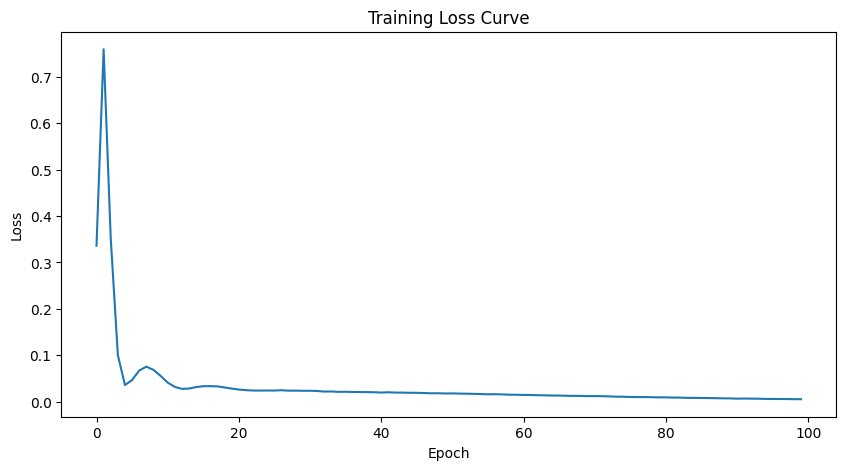

In [20]:
plt.figure(figsize=(10,5))
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [21]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

predictions = predictions.cpu().numpy()
actual = y_test.cpu().numpy()

In [22]:
predictions_rescaled = scaler.inverse_transform(predictions.reshape(-1, 1))
actual_rescaled = scaler.inverse_transform(actual.reshape(-1, 1))

In [23]:
mae = mean_absolute_error(actual_rescaled, predictions_rescaled)
mse = mean_squared_error(actual_rescaled, predictions_rescaled)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_rescaled - predictions_rescaled) / actual_rescaled)) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 332.7680969238281
MSE: 256285.03125
RMSE: 506.2460185028619
MAPE: 10.662564


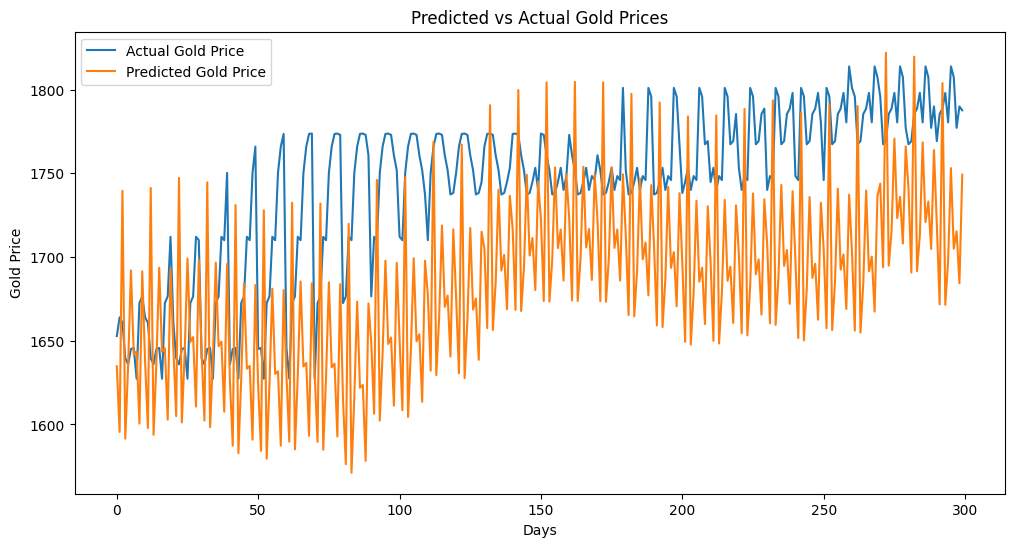

In [24]:
plt.figure(figsize=(12,6))
plt.plot(actual_rescaled[:300], label="Actual Gold Price")
plt.plot(predictions_rescaled[:300], label="Predicted Gold Price")
plt.title("Predicted vs Actual Gold Prices")
plt.xlabel("Days")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

In [25]:
torch.save(model.state_dict(), "gold_transformer_model.pth")